In [19]:
from transformers import logging
logging.set_verbosity_error()

import os
import sys
import re

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import matplotlib.pyplot as plt
import pandas as pd
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.dataset import load_data, get_datasets
from utils.scores import score_summary_rouge, score_summary_bertscore, score_summary_llm


In [5]:
DATASET_PATH = os.path.join("..", "..", "data", "cleaned_datasets", "dataset_lapresse")
SUMMARIES_PATH = os.path.join("..", "..", "data", "summaries", "dataset_lapresse")

assert os.path.exists(DATASET_PATH), f"Dataset not found at {DATASET_PATH}"
assert os.path.exists(SUMMARIES_PATH) and len(os.listdir(SUMMARIES_PATH)) > 0, f"Generate summaries first (or download them)"

## Getting model for LLM score

In [6]:
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
CACHE_DIR = "//Data"
STRUCTURED_PROMPT = True

torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(False)

# Configure 4-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_enable_fp32_cpu_offload=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

# Download and load model into cache directory
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    quantization_config=quantization_config,
    cache_dir=CACHE_DIR,
    attn_implementation="flash_attention_2"
)

# Download and load tokenizer into cache directory
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## Getting the data

In [7]:
data = load_data(DATASET_PATH, SUMMARIES_PATH)

  0%|          | 0/5074 [00:00<?, ?it/s]

100%|██████████| 5074/5074 [00:04<00:00, 1146.67it/s]


In [33]:
CSV_PATH = os.path.join("..", "..", "data", "lapresse_summary_metrics.csv")

def count_words(text):
    words = re.findall(r'\b[a-zA-ZÀ-ÖØ-öø-ÿ]+\b', text)  # matches words with letters only
    return len(words)

def compute_scores(args):
    """Wrapper function to compute ROUGE scores for multiprocessing"""
    filename, initial_text, summary = args
    rouge = score_summary_rouge(initial_text, summary)
    return {
        "filename": filename,
        "initial_length": count_words(initial_text),
        "summary_length": count_words(summary),
        "rouge_1": rouge["ROUGE-1"],
        "rouge_2": rouge["ROUGE-2"],
        "rouge_L": rouge["ROUGE-L"],
        "bert_score": score_summary_bertscore(initial_text, summary, 'cpu'),
        "llm_score": score_summary_llm(model, tokenizer, initial_text, summary),
    }


# load existing CSV if available, otherwise compute metrics
if os.path.exists(CSV_PATH):
    print("Loading precomputed metrics from CSV...")
    df = pd.read_csv(CSV_PATH)

else:
    # Run in parallel using ThreadPoolExecutor (faster for I/O bound tasks)
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(executor.map(compute_scores, data), total=len(data), desc="Evaluating summaries"))

    df = pd.DataFrame(results)
    df.to_csv(CSV_PATH, index=False)

print(df.head())


Loading precomputed metrics from CSV...
                                            filename  initial_length  \
0  #moiaussi hausse des dénonciations d'agressio...             963   
1  Impact une semaine en montagnes russes Pascal ...             860   
2  Il n'y a que de l'humain Michèle Ouimet Miche...            1087   
3  Il n'y aura pas de guerre sur la péninsule, a...            1145   
4  Il nous reste à comprendre Yves Boisvert Yves...             840   

   summary_length   rouge_1   rouge_2   rouge_L  bert_score  llm_score  
0             153  0.227045  0.127090  0.161937    0.714905       0.85  
1             195  0.328959  0.177038  0.234471    0.698369       0.85  
2             155  0.216216  0.111192  0.138787    0.716878       0.85  
3             191  0.260339  0.141208  0.154576    0.732412       0.85  
4             194  0.344395  0.192273  0.251121    0.706911       0.85  


## Plotting metrics

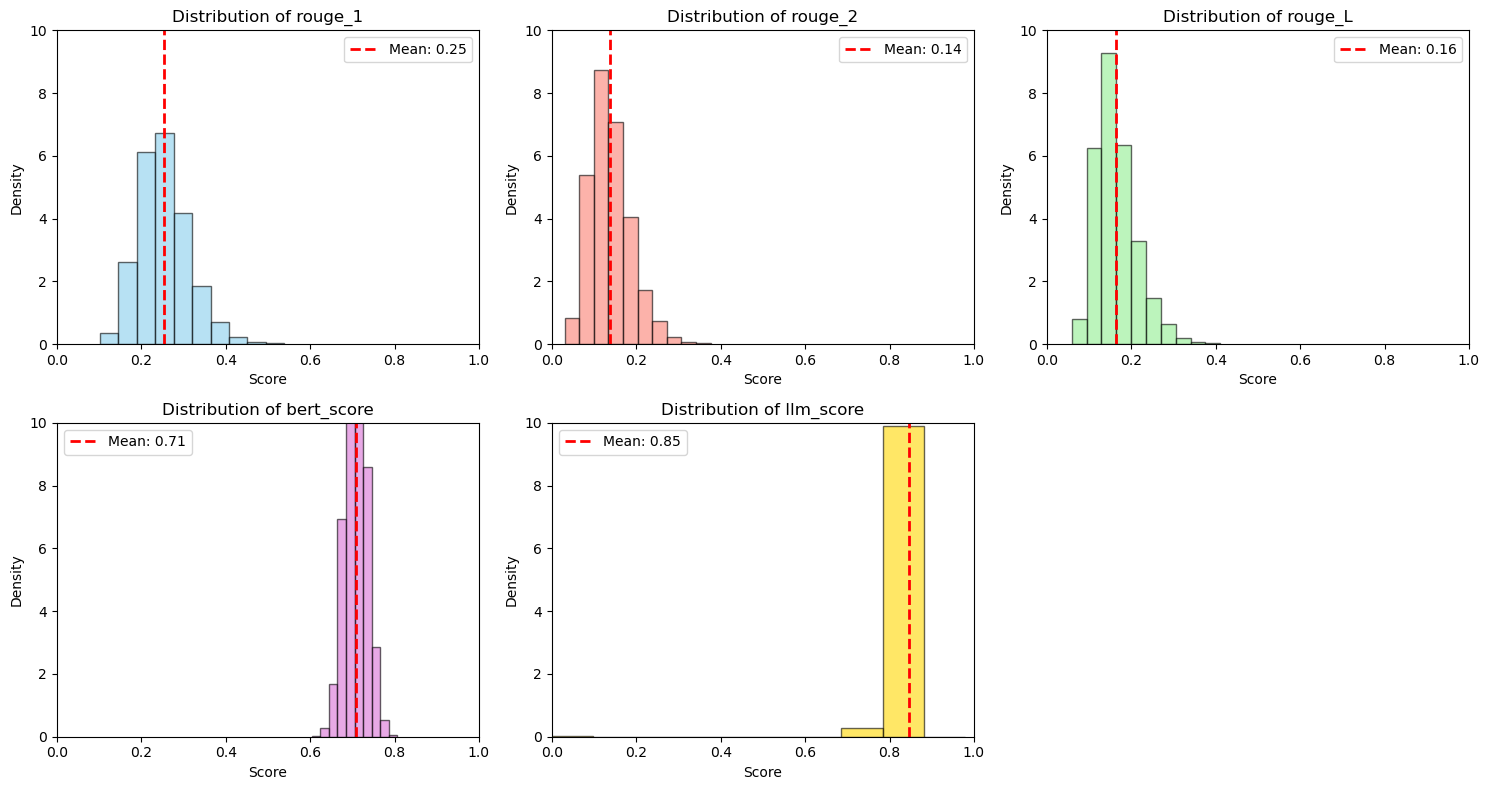

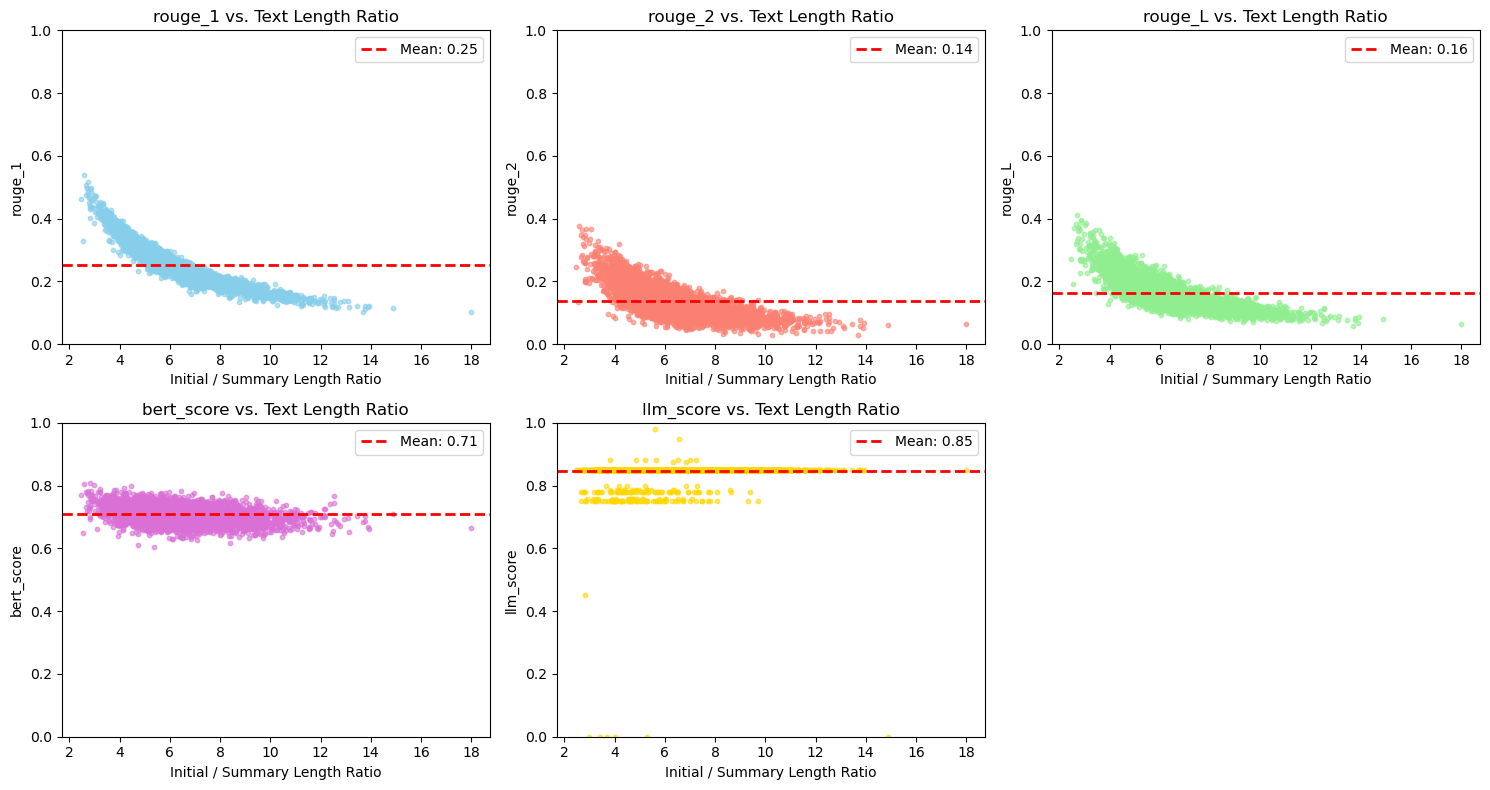

In [34]:
# Define colors for each metric (adding llm_score)
colors = {
    "rouge_1": "skyblue",
    "rouge_2": "salmon",
    "rouge_L": "lightgreen",
    "bert_score": "orchid",
    "llm_score": "gold"
}

# List of metric keys to plot
metrics = list(colors.keys())

# Determine grid layout for 5 metrics: 3 columns by 2 rows (one subplot may remain unused)
num_metrics = len(metrics)
cols = 3
rows = (num_metrics + cols - 1) // cols  # ceil division

# --------------------------
# Figure 1: Histograms
# --------------------------
fig1, axes1 = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes1 = axes1.flatten()

for i, metric in enumerate(metrics):
    ax = axes1[i]
    data_metric = df[metric]
    
    # Plot histogram with density normalization
    counts, bin_edges, _ = ax.hist(
        data_metric, bins=10, color=colors[metric], edgecolor='black',
        alpha=0.6, density=True
    )
    
    # Plot average line
    mean_value = np.mean(data_metric)
    ax.axvline(mean_value, color='red', linestyle="dashed", linewidth=2,
               label=f"Mean: {mean_value:.2f}")
    
    ax.set_title(f"Distribution of {metric}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 10) # max density is 10 cuz n / (min - max) = n with n = number of bins
    ax.legend()
    
# Hide any unused subplot(s)
for j in range(i + 1, len(axes1)):
    axes1[j].set_visible(False)

fig1.tight_layout()
plt.show()

# --------------------------
# Figure 2: Scatter Plots (Text Length Ratio vs. Metrics)
# --------------------------
# Calculate text length ratio for x-axis (initial_length/summary_length)
length_ratio = df['initial_length'] / df['summary_length']

fig2, axes2 = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes2 = axes2.flatten()

for i, metric in enumerate(metrics):
    ax = axes2[i]
    ax.scatter(length_ratio, df[metric], color=colors[metric], alpha=0.6, s=10)
    
    # Plot average horizontal line for the metric
    mean_value = np.mean(df[metric])
    ax.axhline(mean_value, color='red', linestyle="dashed", linewidth=2,
               label=f"Mean: {mean_value:.2f}")
    
    ax.set_title(f"{metric} vs. Text Length Ratio")
    ax.set_xlabel("Initial / Summary Length Ratio")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.legend()
    
# Hide any unused subplot(s)
for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.tight_layout()
plt.show()


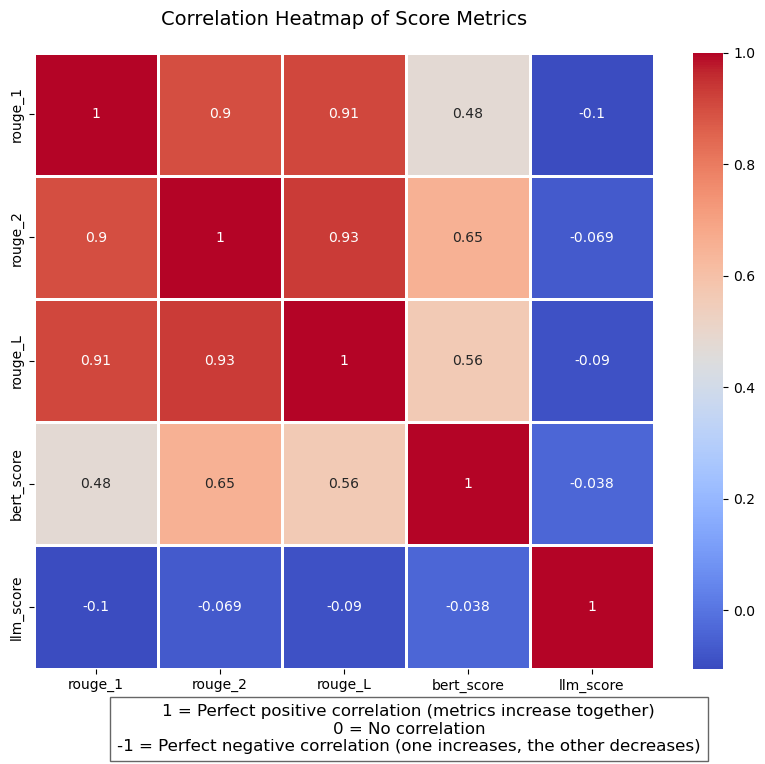

In [35]:
# Compute correlation matrix
corr_matrix = df[["rouge_1", "rouge_2", "rouge_L", "bert_score", "llm_score"]].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=1)

# Add a title
plt.title("Correlation Heatmap of Score Metrics", fontsize=14, pad=20)

# Add a definition below the title
definition = (
    "1 = Perfect positive correlation (metrics increase together)\n"
    "0 = No correlation\n"
    "-1 = Perfect negative correlation (one increases, the other decreases)"
)
plt.figtext(0.5, 0.01, definition, ha="center", fontsize=12, wrap=True, bbox={"facecolor": "white", "alpha": 0.6, "pad": 5})

plt.show()
